In [1]:
print('Hello World.')

Hello World.


In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
def f(x):
    return 3*x**2 - 4*x + 5

In [4]:
f(3.0)

20.0

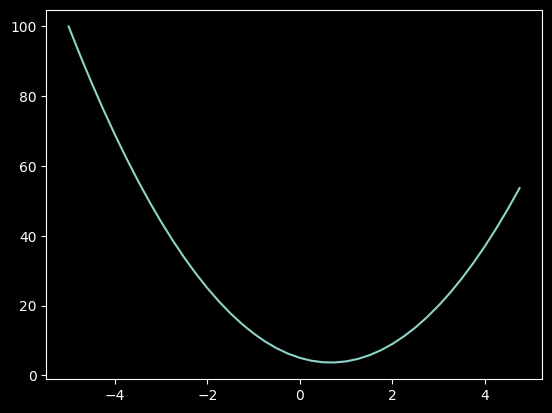

In [5]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)

plt.plot(xs, ys)

In [6]:
h = 0.001
x = 3.0

(f(x+h) - f(x))/ h

14.00300000000243

In [7]:
a = 2.0
b = -3.0
c= 10.0

d = a*b + c
print(d)

4.0


In [8]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
b += h
d2 = a * b + c

print('d1 =', d1)
print('d2 =', d2)

print('slope', (d2 - d1)/h)

d1 = 4.0
d2 = 4.0002
slope 2.0000000000042206


In [9]:
from graphviz import Digraph

def trace(root):
    """Builds a set of all all_edge and all_node in a graph."""

    all_node, all_edge = set(), set()
    def build(vertex):
        if vertex not in all_node:
            all_node.add(vertex)
            for child in vertex._previous:
                all_edge.add((child, vertex))
                build(child)
    build(root)
    return all_node, all_edge

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR indicates Left to Right -->

    all_node, all_edge = trace(root)
    for node in all_node:
        uid = str(id(node))
        # for any value in the graph, create a rectangular node for it. ('record')
        dot.node(name = uid, label = "{ %s | data %.4f | gradient %.4f }" % (node.label, node.data, node.gradient), shape='record')

        if node._operation:
            # if this value is the result of some operation, create an operation node for it.
            dot.node(name = uid + node._operation, label=node._operation)
            # and connect this node to it.
            dot.edge(uid + node._operation, uid)

    for node1, node2 in all_edge:
        # connect n1 to the op node of n2.
        dot.edge(str(id(node1)), str(id(node2)) + node2._operation)

    return dot

In [10]:
class Value:

    def __init__(self, data, _children=(), _operation = '', label = ''):
        self.data = data
        self.gradient = 0
        self._backward = lambda: None
        self._previous = set(_children)
        self._operation = _operation
        self.label = label

    def __repr__(self):
        return f"Value(data = {self.data})"

    def __add__(self, terms):
        out = Value(self.data + terms.data, (self, terms), '+')

        def _backward():
            self.gradient = 1.0 * out.gradient
            terms.gradient = 1.0 * out.gradient
        out._backward = _backward

        return out

    def __mul__(self, terms):
        out = Value(self.data * terms.data, (self, terms), '*')

        def _backward():
            self.gradient = terms.data * out.gradient
            terms.gradient = self.data * out.gradient
        out._backward = _backward

        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.gradient = (1 - t**2) * out.gradient
        out._backward = _backward

        return out

    def backward(self):
        all_node_topological_list = []

        visited = set()
        def build_topological_list(vertex):
            if vertex not in visited:
                visited.add(vertex)
                for child in vertex._previous:
                    build_topological_list(child)
                all_node_topological_list.append(vertex)
        build_topological_list(self)

        self.gradient = 1.0
        for node in reversed(all_node_topological_list):
            node._backward()




In [11]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')

e = a*b
e.label = 'e'

d = e + c
d.label = 'd'

f = Value(-2.0, label='f')

L = d * f; L.label = 'L'
L

Value(data = -8.0)

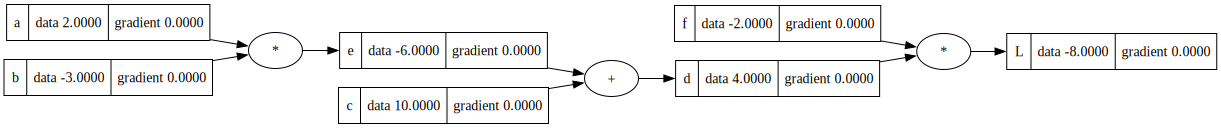

In [12]:
draw_dot(L)

In [13]:
# L = d * f

# f(x+h) - f(x)/h

#     ((d+h)*f - d*f)/h
# --> (d*f + h*f - d*f)/h
# --> (h*f) / h
# --> f

In [14]:
L.gradient = 1.0

In [15]:
def lol():

    h = 0.001
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    b.data+=h
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data


    print((L2-L1)/h)

lol()


-3.9999999999995595


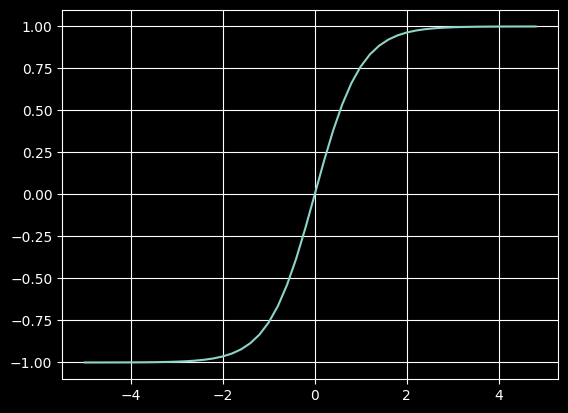

In [16]:
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2)))
plt.grid()

In [17]:
# inputs x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias
b = Value(6.8813735870195432, label='b')

x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'output'


In [18]:
# o.gradient = 1.0
# 1 - o.data**2

In [19]:
# n.gradient = 0.5
# x1w1x2w2.gradient = 0.5
# b.gradient = 0.5
#
# x1w1.gradient = 0.5
# x2w2.gradient = 0.5
#
# x2.gradient = x2w2.gradient * w2.data
# w2.gradient = x2w2.gradient * x2.data
#
# w1.gradient = x1w1.gradient * x1.data
# x1.gradient = x1w1.gradient * w1.data

In [20]:
# o.gradient = 1.0
# o._backward()
# n._backward()
# b._backward()
# x1w1x2w2._backward()
# x2w2._backward()
# x1w1._backward()
#
# draw_dot(o)
#


In [21]:
# Implement topological sort to remove redundant calling of ._backward()

In [22]:
all_node_topological_list = []

visited = set()
def build_topological_list(vertex):
    if vertex not in visited:
        visited.add(vertex)
        for child in vertex._previous:
            build_topological_list(child)
        all_node_topological_list.append(vertex)

build_topological_list(o)
all_node_topological_list

[Value(data = 0.0),
 Value(data = 1.0),
 Value(data = 0.0),
 Value(data = 2.0),
 Value(data = -3.0),
 Value(data = -6.0),
 Value(data = -6.0),
 Value(data = 6.881373587019543),
 Value(data = 0.8813735870195432),
 Value(data = 0.7071067811865476)]

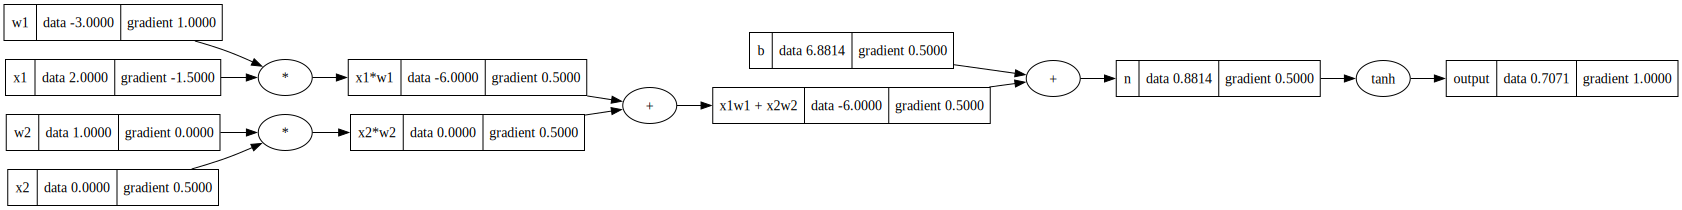

In [24]:
o.backward()

draw_dot(o)